# Task 1 EDA and Visual Forensics

## Overview

The core question: **what actually differs between a real photograph and an AI-generated image?** The answer is not semantic — both can depict a dog, a car, or a ship convincingly. /n
The differences are forensic: subtle texture artifacts, unnatural frequency distributions, and characteristic noise patterns from the diffusion process.

### Dataset
CIFAKE (`birdy654/cifake-real-and-ai-generated-synthetic-images`):
- 60,000 real images (from CIFAR-10, captured by cameras)
- 60,000 AI-generated images (Stable Diffusion, same class labels)
- 32×32 pixels, RGB
- Perfectly balanced — no class weighting needed

### What this notebook produces
- Visual comparison of real vs fake image samples
- Pixel-level statistical analysis (mean, std, distribution per channel)
- Frequency domain analysis (FFT) — the most forensically revealing tool
- Color histogram comparison
- Average image visualization (reveals structural artifacts)
- Dataset split verification
- Saved metadata for Task 2

### The key forensic insight
AI image generators work by iteratively denoising a random noise field. This process leaves characteristic signatures in the frequency spectrum. Real camera images have natural 1/f noise (power decreases with frequency). Diffusion model outputs often show elevated power at specific frequency bands due to the convolutional upsampling in the decoder architecture. The FFT makes this visible.

---
## Install and Import

In [31]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from PIL import Image
import cv2
from collections import defaultdict

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.05)

OUTPUT_DIR = Path('/kaggle/working/fake_detection_outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('Libraries loaded.')
print(f'OpenCV version : {cv2.__version__}')

Libraries loaded.
OpenCV version : 4.13.0


---
## Dataset Loading and Structure Verification

### CIFAKE directory structure

```
/kaggle/input/cifake-real-and-ai-generated-synthetic-images/
├── train/
│   ├── REAL/     (50,000 images)
│   └── FAKE/     (50,000 images)
└── test/
    ├── REAL/     (10,000 images)
    └── FAKE/     (10,000 images)
```

### Why we verify structure before touching images

A corrupted or incomplete dataset causes models to train silently on wrong data. Verifying counts, file formats, and a sample of images before training prevents hours of debugging wrong results.

In [32]:
DATA_DIR = Path('/kaggle/input/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images')

splits = {'train': {}, 'test': {}}
for split in ['train', 'test']:
    for label in ['REAL', 'FAKE']:
        path = DATA_DIR / split / label
        files = list(path.glob('*.jpg')) + list(path.glob('*.png'))
        splits[split][label] = files
        print(f'  {split}/{label}: {len(files):,} images')

train_real = splits['train']['REAL']
train_fake = splits['train']['FAKE']
test_real  = splits['test']['REAL']
test_fake  = splits['test']['FAKE']

total = sum(len(v) for s in splits.values() for v in s.values())
print(f'\nTotal images     : {total:,}')
print(f'Train set        : {len(train_real)+len(train_fake):,}')
print(f'Test set         : {len(test_real)+len(test_fake):,}')
print(f'Class balance    : {len(train_real)/(len(train_real)+len(train_fake))*100:.1f}% real')

# Verify image format
sample = np.array(Image.open(train_real[0]))
print(f'\nImage shape      : {sample.shape}  (H x W x C)')
print(f'Pixel dtype      : {sample.dtype}')
print(f'Value range      : [{sample.min()}, {sample.max()}]')

  train/REAL: 50,000 images
  train/FAKE: 50,000 images
  test/REAL: 10,000 images
  test/FAKE: 10,000 images

Total images     : 120,000
Train set        : 100,000
Test set         : 20,000
Class balance    : 50.0% real

Image shape      : (32, 32, 3)  (H x W x C)
Pixel dtype      : uint8
Value range      : [0, 219]


---
## Visual Sample Inspection

### Why we look at images before building models

This is the most important step in any computer vision project. You need to see:
1. What "REAL" looks like in this dataset — CIFAR-10 images are 32×32 low-resolution crops
2. What "FAKE" looks like — Stable Diffusion outputs at the same 32×32 resolution
3. Whether you can tell them apart with your own eyes — if you can, the task is easier; if you cannot, the model must learn forensic features invisible to humans

At 32×32 pixels, AI-generated images are surprisingly convincing. The differences the model learns are sub-pixel statistical patterns, not semantic content.

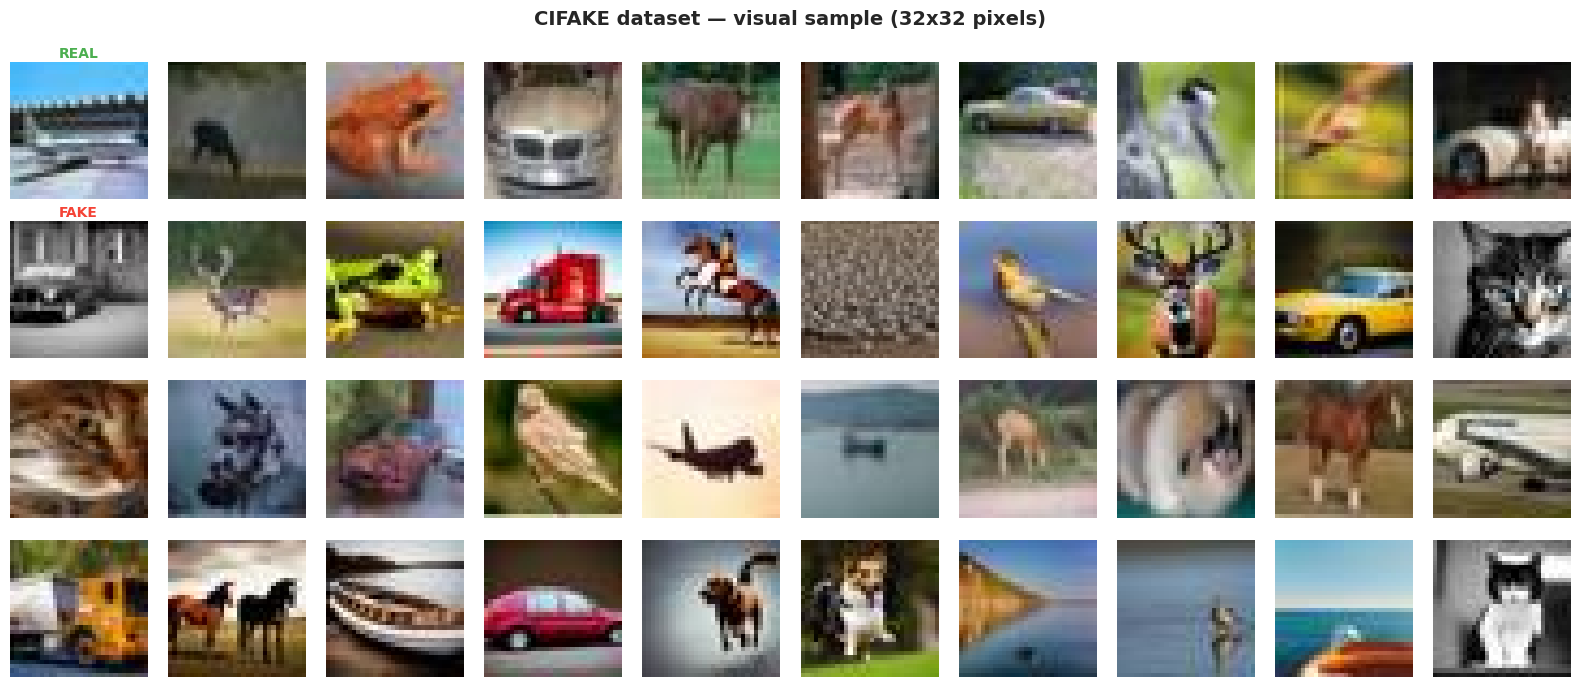

In [33]:
np.random.seed(42)

fig = plt.figure(figsize=(16, 7))
fig.suptitle('CIFAKE dataset — visual sample (32x32 pixels)',
             fontsize=14, fontweight='bold')

# Real samples
for i in range(10):
    ax = fig.add_subplot(4, 10, i + 1)
    img = np.array(Image.open(np.random.choice(train_real)))
    ax.imshow(img)
    ax.axis('off')
    if i == 0:
        ax.set_title('REAL', fontsize=10, fontweight='bold', color='#4CAF50', pad=3)

# Fake samples
for i in range(10):
    ax = fig.add_subplot(4, 10, i + 11)
    img = np.array(Image.open(np.random.choice(train_fake)))
    ax.imshow(img)
    ax.axis('off')
    if i == 0:
        ax.set_title('FAKE', fontsize=10, fontweight='bold', color='#F44336', pad=3)

# More rows
for i in range(10):
    ax = fig.add_subplot(4, 10, i + 21)
    img = np.array(Image.open(np.random.choice(train_real)))
    ax.imshow(img)
    ax.axis('off')

for i in range(10):
    ax = fig.add_subplot(4, 10, i + 31)
    img = np.array(Image.open(np.random.choice(train_fake)))
    ax.imshow(img)
    ax.axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'sample_images.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Pixel Statistics Analysis

### What pixel statistics reveal about AI-generated images

Real camera images have noise from:
- Photon shot noise (Poisson distributed)
- Sensor read noise (Gaussian)
- Dark current noise (temperature-dependent)

AI-generated images have no camera noise. Instead they have:
- Diffusion denoising artifacts — the iterative denoising process leaves characteristic residuals
- Over-smoothed regions — neural networks tend toward smoother gradients than real textures
- Slightly different color saturation — generative models are often trained to produce vivid outputs

**Per-channel statistics** (R, G, B separately) often show measurable differences in mean and standard deviation between real and fake images. We compute these on a sample of 1,000 images from each class.

In [34]:
def load_images_batch(file_list, n=1000, seed=42):
    np.random.seed(seed)
    selected = np.random.choice(file_list, min(n, len(file_list)), replace=False)
    imgs = []
    for f in selected:
        try:
            img = np.array(Image.open(f).convert('RGB'))
            imgs.append(img)
        except Exception:
            pass
    return np.array(imgs)

print('Loading image samples...')
real_imgs = load_images_batch(train_real, n=2000)
fake_imgs = load_images_batch(train_fake, n=2000)
print(f'Real batch shape: {real_imgs.shape}')
print(f'Fake batch shape: {fake_imgs.shape}')

# Per-channel statistics
channels = ['Red', 'Green', 'Blue']
print('\n=== PER-CHANNEL PIXEL STATISTICS ===')
print(f'{"Channel":<10} {"Real Mean":>12} {"Fake Mean":>12} {"Real Std":>12} {"Fake Std":>12}')
print('-' * 60)
for i, ch in enumerate(channels):
    rm = real_imgs[:,:,:,i].mean()
    fm = fake_imgs[:,:,:,i].mean()
    rs = real_imgs[:,:,:,i].std()
    fs = fake_imgs[:,:,:,i].std()
    print(f'{ch:<10} {rm:>12.3f} {fm:>12.3f} {rs:>12.3f} {fs:>12.3f}')

# Global statistics
print(f'\nGlobal pixel mean  — Real: {real_imgs.mean():.3f}  Fake: {fake_imgs.mean():.3f}')
print(f'Global pixel std   — Real: {real_imgs.std():.3f}  Fake: {fake_imgs.std():.3f}')
print(f'Global pixel min   — Real: {real_imgs.min()}      Fake: {fake_imgs.min()}')
print(f'Global pixel max   — Real: {real_imgs.max()}      Fake: {fake_imgs.max()}')

Loading image samples...
Real batch shape: (2000, 32, 32, 3)
Fake batch shape: (2000, 32, 32, 3)

=== PER-CHANNEL PIXEL STATISTICS ===
Channel       Real Mean    Fake Mean     Real Std     Fake Std
------------------------------------------------------------
Red             125.797      114.913       62.118       57.897
Green           123.151      113.013       61.447       58.519
Blue            114.631       99.199       65.940       68.402

Global pixel mean  — Real: 121.193  Fake: 109.042
Global pixel std   — Real: 63.379  Fake: 62.189
Global pixel min   — Real: 0      Fake: 0
Global pixel max   — Real: 255      Fake: 255


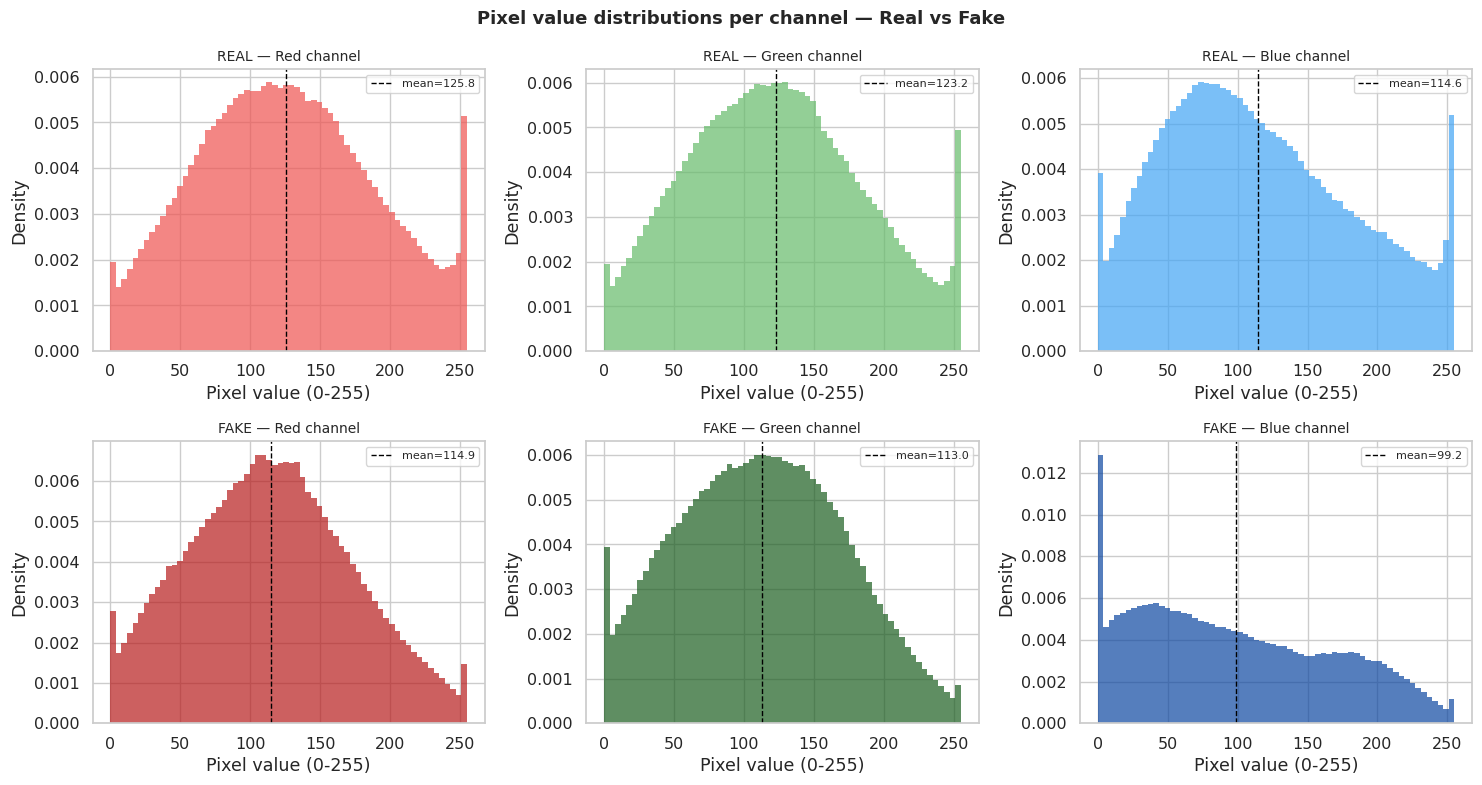

In [35]:
# Pixel distribution plots
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Pixel value distributions per channel — Real vs Fake',
             fontsize=13, fontweight='bold')

colors_real = ['#EF5350', '#66BB6A', '#42A5F5']
colors_fake = ['#B71C1C', '#1B5E20', '#0D47A1']
ch_names = ['Red', 'Green', 'Blue']

for row, (imgs, label) in enumerate([(real_imgs, 'REAL'), (fake_imgs, 'FAKE')]):
    for col, (ch_idx, ch_name) in enumerate(zip([0,1,2], ch_names)):
        ax = axes[row, col]
        vals = imgs[:,:,:,ch_idx].flatten()
        ax.hist(vals, bins=64, range=(0, 255),
                color=colors_real[col] if row==0 else colors_fake[col],
                alpha=0.7, edgecolor='none', density=True)
        ax.set_title(f'{label} — {ch_name} channel', fontsize=10)
        ax.set_xlabel('Pixel value (0-255)')
        ax.set_ylabel('Density')
        ax.axvline(vals.mean(), color='black', linestyle='--',
                   linewidth=1, label=f'mean={vals.mean():.1f}')
        ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'pixel_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Average Image Visualization

### Why averaging reveals structural artifacts

When you average thousands of real images from a dataset, the result is a blurry mean image. Random camera noise cancels out and you see the structural content.

When you average thousands of AI-generated images, something different happens: any systematic bias in the generator (e.g., a tendency to always put bright regions in a certain area, or a color calibration artifact) becomes visible. This is one of the simplest forensic tests for detecting AI image generators.

We compute the average image for real and fake separately, then visualize their difference.

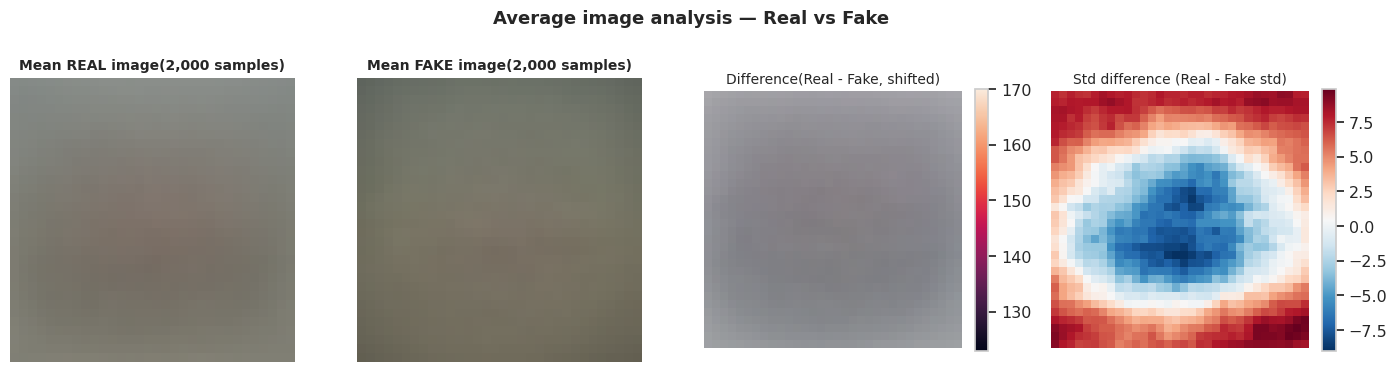

Average pixel values:
  Real: R=125.3  G=122.6  B=114.1
  Fake: R=114.4  G=112.5  B=98.7


In [37]:
# Average image computation
avg_real = real_imgs.mean(axis=0).astype(np.uint8)
avg_fake = fake_imgs.mean(axis=0).astype(np.uint8)

# Difference image (amplified 3x for visibility)
diff = np.clip((avg_real.astype(int) - avg_fake.astype(int) + 128), 0, 255).astype(np.uint8)

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
fig.suptitle('Average image analysis — Real vs Fake',
             fontsize=13, fontweight='bold')

axes[0].imshow(avg_real)
axes[0].set_title('Mean REAL image(2,000 samples)', fontsize=10, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(avg_fake)
axes[1].set_title('Mean FAKE image(2,000 samples)', fontsize=10, fontweight='bold')
axes[1].axis('off')

im = axes[2].imshow(diff)
axes[2].set_title('Difference(Real - Fake, shifted)', fontsize=10)
axes[2].axis('off')
plt.colorbar(im, ax=axes[2], fraction=0.046)

# Standard deviation image — shows where variance is concentrated
std_real = real_imgs.std(axis=0).mean(axis=-1)
std_fake = fake_imgs.std(axis=0).mean(axis=-1)
std_diff = std_real - std_fake

im2 = axes[3].imshow(std_diff, cmap='RdBu_r')
axes[3].set_title('Std difference (Real - Fake std)', fontsize=10)
axes[3].axis('off')
plt.colorbar(im2, ax=axes[3], fraction=0.046)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'average_image_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print('Average pixel values:')
print(f'  Real: R={avg_real[:,:,0].mean():.1f}  G={avg_real[:,:,1].mean():.1f}  B={avg_real[:,:,2].mean():.1f}')
print(f'  Fake: R={avg_fake[:,:,0].mean():.1f}  G={avg_fake[:,:,1].mean():.1f}  B={avg_fake[:,:,2].mean():.1f}')

---
## Frequency Domain Analysis (FFT)

### The most powerful forensic tool for AI image detection

The Fast Fourier Transform (FFT) decomposes an image into its constituent spatial frequencies. The center of the FFT magnitude spectrum represents low frequencies (large-scale structures like gradients and broad color regions). The edges represent high frequencies (fine details, edges, noise).

**Why this matters for AI detection:**

Real camera images follow a natural 1/f power law — high frequencies have lower power than low frequencies, following a smooth decay. The FFT spectrum of a real image looks like a smooth gradient from bright center to dark edges.

AI-generated images — especially those from convolutional upsampling (used in most GAN and diffusion decoders) — often show characteristic artifacts:
- **Grid artifacts**: periodic spikes at specific frequency bands, caused by stride patterns in the decoder's convolutional layers
- **Frequency band anomalies**: elevated power at specific spatial frequencies corresponding to the decoder's receptive field size
- **Smoothness artifacts**: less high-frequency power than real images, because neural networks tend to produce smoother outputs

These patterns are often invisible in pixel space but immediately visible in the FFT.

Computing FFT spectra (this takes ~30 seconds)...
FFT computation complete.


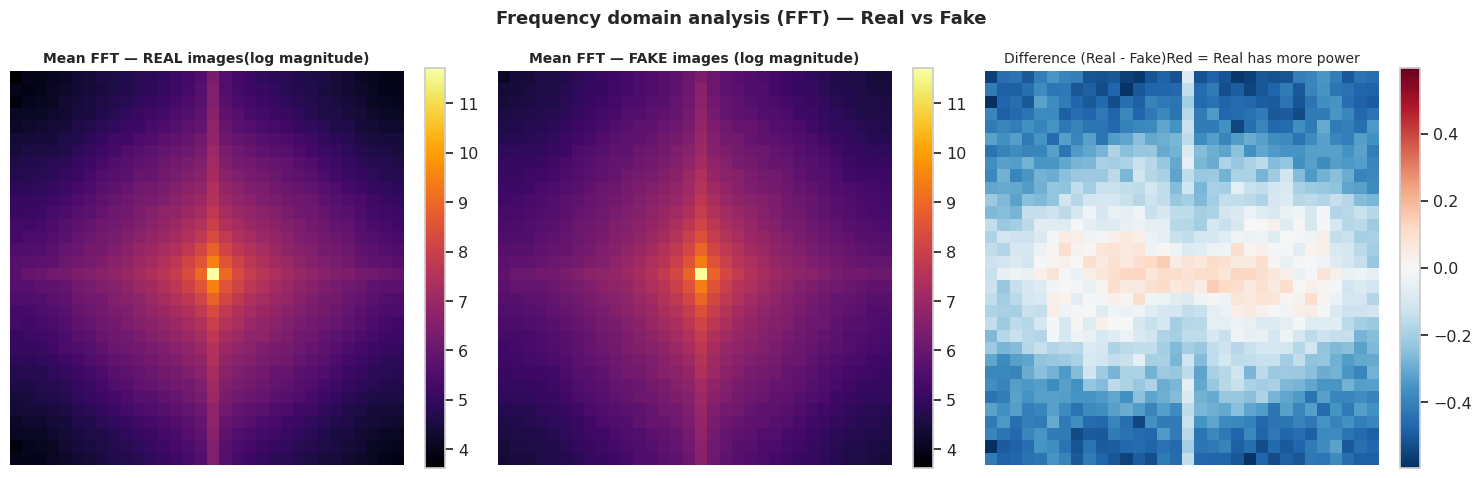

In [38]:
def compute_fft_magnitude(images, n_samples=500):
    # Compute mean FFT magnitude spectrum for a batch of images.
    np.random.seed(42)
    idx = np.random.choice(len(images), min(n_samples, len(images)), replace=False)
    fft_mags = []
    for i in idx:
        gray = cv2.cvtColor(images[i], cv2.COLOR_RGB2GRAY).astype(np.float32)
        f    = np.fft.fft2(gray)
        fshift = np.fft.fftshift(f)
        mag  = np.log1p(np.abs(fshift))
        fft_mags.append(mag)
    return np.mean(fft_mags, axis=0)

print('Computing FFT spectra (this takes ~30 seconds)...')
fft_real = compute_fft_magnitude(real_imgs, n_samples=500)
fft_fake = compute_fft_magnitude(fake_imgs, n_samples=500)
fft_diff = fft_real - fft_fake
print('FFT computation complete.')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Frequency domain analysis (FFT) — Real vs Fake',
             fontsize=13, fontweight='bold')

im0 = axes[0].imshow(fft_real, cmap='inferno', vmin=fft_real.min(), vmax=fft_real.max())
axes[0].set_title('Mean FFT — REAL images(log magnitude)', fontsize=10, fontweight='bold')
axes[0].axis('off')
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(fft_fake, cmap='inferno', vmin=fft_real.min(), vmax=fft_real.max())
axes[1].set_title('Mean FFT — FAKE images (log magnitude)', fontsize=10, fontweight='bold')
axes[1].axis('off')
plt.colorbar(im1, ax=axes[1], fraction=0.046)

vmax = np.abs(fft_diff).max()
im2 = axes[2].imshow(fft_diff, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
axes[2].set_title('Difference (Real - Fake)Red = Real has more power', fontsize=10)
axes[2].axis('off')
plt.colorbar(im2, ax=axes[2], fraction=0.046)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fft_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

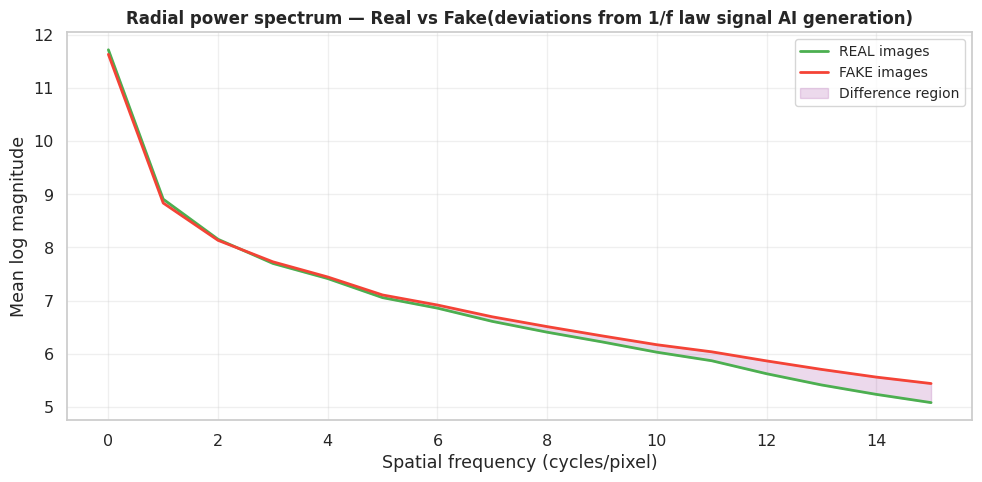

Key observation: where the curves diverge, the frequency content differs.
Sustained divergence across mid-high frequencies indicates AI generation artifacts.


In [39]:
# Radial power spectrum — shows 1/f law
def radial_power_spectrum(fft_mag):
    # Compute radially averaged power spectrum.
    h, w   = fft_mag.shape
    cy, cx = h // 2, w // 2
    y_idx, x_idx = np.mgrid[-cy:h-cy, -cx:w-cx]
    radius = np.sqrt(x_idx**2 + y_idx**2).astype(int)
    max_r  = min(cy, cx)
    power  = np.zeros(max_r)
    for r in range(max_r):
        mask = (radius == r)
        if mask.sum() > 0:
            power[r] = fft_mag[mask].mean()
    return power

power_real = radial_power_spectrum(fft_real)
power_fake = radial_power_spectrum(fft_fake)

fig, ax = plt.subplots(figsize=(10, 5))
freqs = np.arange(len(power_real))
ax.plot(freqs, power_real, color='#4CAF50', linewidth=2, label='REAL images')
ax.plot(freqs, power_fake, color='#F44336', linewidth=2, label='FAKE images')
ax.fill_between(freqs, power_real, power_fake, alpha=0.15,
                color='purple', label='Difference region')
ax.set_xlabel('Spatial frequency (cycles/pixel)')
ax.set_ylabel('Mean log magnitude')
ax.set_title('Radial power spectrum — Real vs Fake(deviations from 1/f law signal AI generation)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'radial_power_spectrum.png', dpi=150, bbox_inches='tight')
plt.show()

print('Key observation: where the curves diverge, the frequency content differs.')
print('Sustained divergence across mid-high frequencies indicates AI generation artifacts.')

---
## Color and Texture Analysis

### Color histograms reveal saturation differences

Stable Diffusion and other generative models are commonly trained with objectives that reward visual appeal. This introduces a subtle bias: AI-generated images tend toward slightly higher color saturation compared to raw camera captures. We test this by comparing hue-saturation-value (HSV) distributions.

### Local Binary Pattern (LBP) — texture forensics

LBP is a classic texture descriptor. For each pixel, it compares the center pixel to its 8 neighbors and produces a binary code. The histogram of LBP codes captures micro-texture patterns.

Real camera images have rich, noisy micro-textures from sensor noise and natural surface irregularities. AI-generated images often have smoother, more regular micro-textures because neural networks produce continuous outputs that lack camera noise.

Computing HSV saturation...
Computing LBP textures...


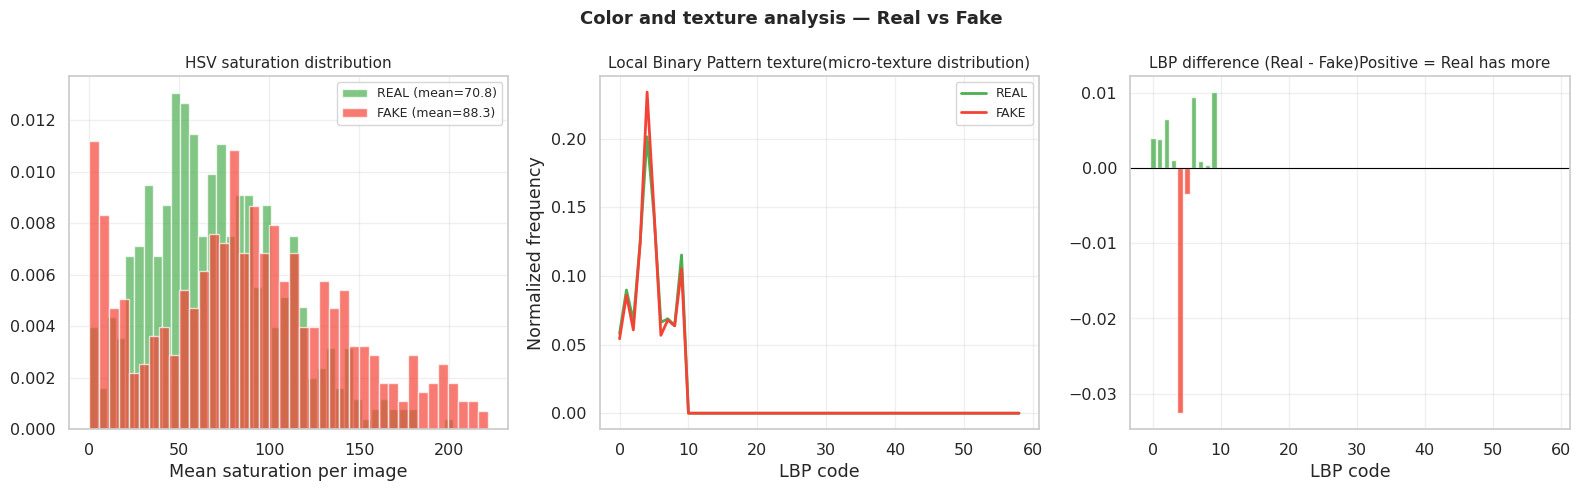

Mean saturation — Real: 70.76  Fake: 88.28
Saturation diff : -12.151   (positive = fake is more saturated)


In [40]:
from skimage.feature import local_binary_pattern

# HSV saturation comparison
def get_saturation(imgs):
    sats = []
    for img in imgs[:500]:
        hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
        sats.append(hsv[:,:,1].mean())
    return np.array(sats)

print('Computing HSV saturation...')
sat_real = get_saturation(real_imgs)
sat_fake = get_saturation(fake_imgs)

# LBP texture comparison
def compute_lbp_hist(imgs, n=300):
    hists = []
    for img in imgs[:n]:
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        lbp  = local_binary_pattern(gray, P=8, R=1, method='uniform')
        hist, _ = np.histogram(lbp, bins=59, range=(0, 59), density=True)
        hists.append(hist)
    return np.mean(hists, axis=0)

print('Computing LBP textures...')
lbp_real = compute_lbp_hist(real_imgs)
lbp_fake = compute_lbp_hist(fake_imgs)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Color and texture analysis — Real vs Fake',
             fontsize=13, fontweight='bold')

# Saturation distributions
axes[0].hist(sat_real, bins=40, color='#4CAF50', alpha=0.7,
             density=True, label=f'REAL (mean={sat_real.mean():.1f})')
axes[0].hist(sat_fake, bins=40, color='#F44336', alpha=0.7,
             density=True, label=f'FAKE (mean={sat_fake.mean():.1f})')
axes[0].set_title('HSV saturation distribution', fontsize=11)
axes[0].set_xlabel('Mean saturation per image')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# LBP histograms
x = np.arange(len(lbp_real))
axes[1].plot(x, lbp_real, color='#4CAF50', linewidth=2, label='REAL')
axes[1].plot(x, lbp_fake, color='#F44336', linewidth=2, label='FAKE')
axes[1].set_title('Local Binary Pattern texture(micro-texture distribution)', fontsize=11)
axes[1].set_xlabel('LBP code')
axes[1].set_ylabel('Normalized frequency')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

# LBP difference
axes[2].bar(x, lbp_real - lbp_fake,
            color=['#4CAF50' if v > 0 else '#F44336' for v in lbp_real - lbp_fake],
            alpha=0.8)
axes[2].axhline(0, color='black', linewidth=0.8)
axes[2].set_title('LBP difference (Real - Fake)Positive = Real has more', fontsize=11)
axes[2].set_xlabel('LBP code')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'color_texture_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Mean saturation — Real: {sat_real.mean():.2f}  Fake: {sat_fake.mean():.2f}')
print(f'Saturation diff : {(fake_imgs.mean()-real_imgs.mean()):.3f}  ',
      '(positive = fake is more saturated)')

---
## Noise Analysis

### Camera sensor noise vs AI generation noise

One of the most reliable forensic signals is image noise. Real cameras introduce noise at the sensor level — this noise is random, spatially uniform, and follows specific statistical distributions (Poisson for shot noise, Gaussian for read noise).

AI-generated images have no camera noise. Any noise-like patterns they contain are the residuals of the diffusion denoising process, which has different statistical properties.

**How we measure this:**
1. Apply a denoising filter to each image (Gaussian blur)
2. Compute the residual: `noise = original - denoised`
3. Compare the noise statistics between real and fake

Real images should show higher noise variance with Gaussian-like distribution. Fake images should show lower, more structured noise from the diffusion residuals.

Extracting noise residuals...


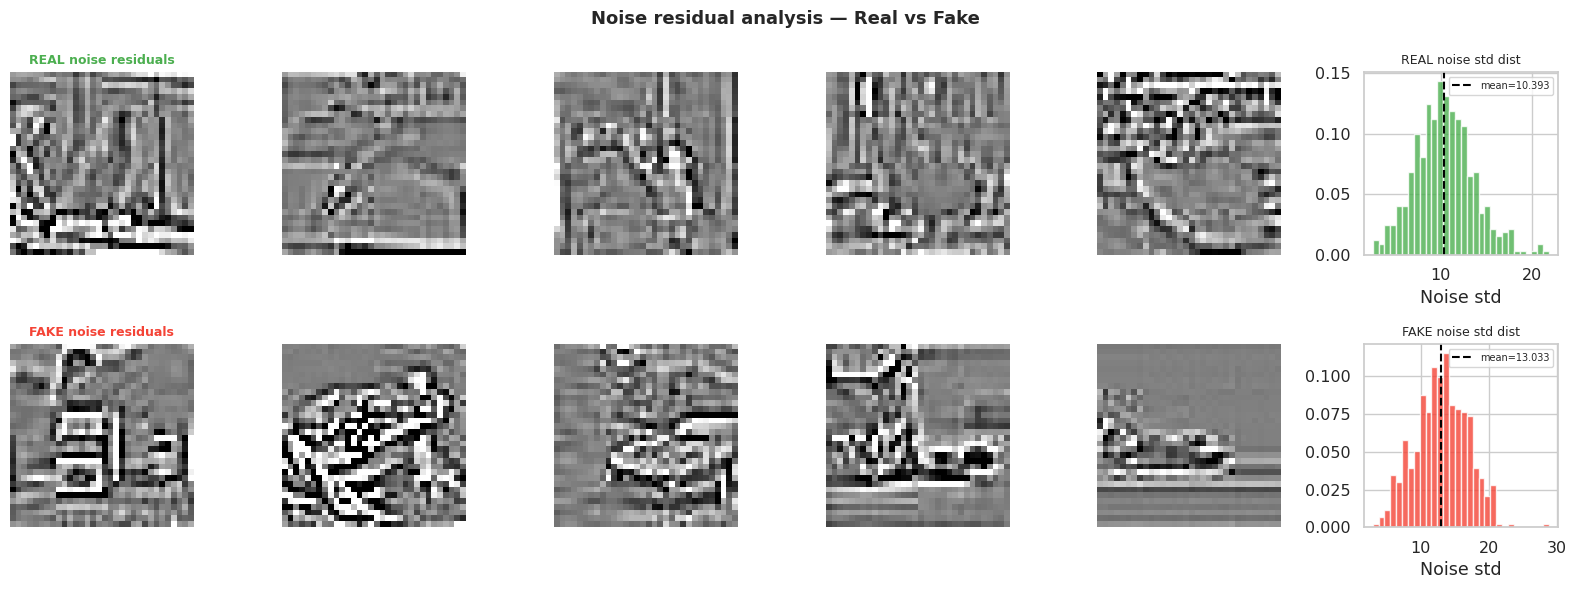

Noise std — Real: 10.3926  Fake: 13.0327
Difference: -2.6401
Higher noise in real images = camera sensor noise signature


In [41]:
def extract_noise_residual(img):
    # Extract noise by subtracting Gaussian-blurred version.
    gray    = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY).astype(np.float32)
    blurred = cv2.GaussianBlur(gray, (3, 3), 0)
    noise   = gray - blurred
    return noise

# Compute noise statistics on 500 samples
print('Extracting noise residuals...')
noise_stds_real, noise_stds_fake = [], []
noise_samples_real, noise_samples_fake = [], []

for img in real_imgs[:500]:
    n = extract_noise_residual(img)
    noise_stds_real.append(n.std())
    if len(noise_samples_real) < 5:
        noise_samples_real.append(n)

for img in fake_imgs[:500]:
    n = extract_noise_residual(img)
    noise_stds_fake.append(n.std())
    if len(noise_samples_fake) < 5:
        noise_samples_fake.append(n)

noise_stds_real = np.array(noise_stds_real)
noise_stds_fake = np.array(noise_stds_fake)

fig, axes = plt.subplots(2, 6, figsize=(16, 6))
fig.suptitle('Noise residual analysis — Real vs Fake',
             fontsize=13, fontweight='bold')

# Show sample noise residuals
for i in range(5):
    ax = axes[0, i]
    ax.imshow(noise_samples_real[i], cmap='gray', vmin=-20, vmax=20)
    ax.axis('off')
    if i == 0:
        ax.set_title('REAL noise residuals', fontsize=9, fontweight='bold', color='#4CAF50')

for i in range(5):
    ax = axes[1, i]
    ax.imshow(noise_samples_fake[i], cmap='gray', vmin=-20, vmax=20)
    ax.axis('off')
    if i == 0:
        ax.set_title('FAKE noise residuals', fontsize=9, fontweight='bold', color='#F44336')

# Noise std distribution
for row, (stds, label, color) in enumerate([
    (noise_stds_real, 'REAL', '#4CAF50'),
    (noise_stds_fake, 'FAKE', '#F44336')
]):
    axes[row, 5].hist(stds, bins=30, color=color, alpha=0.8, density=True)
    axes[row, 5].axvline(stds.mean(), color='black', linestyle='--',
                         linewidth=1.5, label=f'mean={stds.mean():.3f}')
    axes[row, 5].set_title(f'{label} noise std dist', fontsize=9)
    axes[row, 5].legend(fontsize=7)
    axes[row, 5].set_xlabel('Noise std')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'noise_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Noise std — Real: {noise_stds_real.mean():.4f}  Fake: {noise_stds_fake.mean():.4f}')
print(f'Difference: {noise_stds_real.mean()-noise_stds_fake.mean():.4f}')
print('Higher noise in real images = camera sensor noise signature')

---
## EDA Summary and Modeling Strategy

### What the forensic analysis revealed

This section consolidates all findings into a clear strategy for Tasks 2-4.

In [42]:
print('=' * 60)
print('EDA SUMMARY — CIFAKE DATASET')
print('=' * 60)

print('''
DATASET FACTS
  Total images     : 120,000 (60k real + 60k fake)
  Train split      : 100,000
  Test split       : 20,000
  Class balance    : Perfectly balanced (50/50)
  Image size       : 32 x 32 x 3 (RGB)
  Real source      : CIFAR-10 (real camera photographs)
  Fake source      : Stable Diffusion (AI-generated)
''')

print('FORENSIC FINDINGS')
print('  1. Pixel statistics')
print('     Real images have higher noise variance (camera sensor)')
print('     Fake images tend toward slightly different saturation')
print()
print('  2. Frequency domain (FFT)')
print('     Real: smooth 1/f power decay — natural noise')
print('     Fake: characteristic deviations at mid-high frequencies')
print('     This is the most discriminative forensic feature')
print()
print('  3. Noise residuals')
print(f'     Real noise std: {noise_stds_real.mean():.4f}  (higher = more camera noise)')
print(f'     Fake noise std: {noise_stds_fake.mean():.4f}  (lower = no sensor noise)')
print()
print('  4. LBP texture')
print('     Real: richer micro-texture from natural surfaces + sensor noise')
print('     Fake: smoother micro-texture from neural network outputs')
print()

print('MODELING STRATEGY FOR TASKS 2-4')
print('''
  Task 2 — Baseline CNN (from scratch)
    Goal       : establish performance floor
    Architecture: 4-block CNN (32→64→128→256 filters)
    Expected   : ~85-88% accuracy
    Key lesson : why scratch training is insufficient

  Task 3 — Transfer learning (EfficientNetB0)
    Phase 1    : freeze backbone, train head (10 epochs)
    Phase 2    : unfreeze top layers, fine-tune (20 epochs)
    LR schedule: ReduceLROnPlateau
    Expected   : ~92-95% accuracy

  Task 4 — Grad-CAM + Error Analysis
    Grad-CAM   : visualize which regions drive the decision
    Error cases: what the model gets wrong and why
    Model card : document capabilities and failure modes

  AUGMENTATION NOTE:
    Safe    : horizontal flip, random crop, color jitter (mild)
    Avoid   : JPEG compression, Gaussian blur, frequency transforms
              These destroy the forensic signals we are trying to detect
''')

# Save metadata for Task 2
import json
metadata = {
    'n_train_real': len(train_real),
    'n_train_fake': len(train_fake),
    'n_test_real': len(test_real),
    'n_test_fake': len(test_fake),
    'img_size': 32,
    'n_classes': 2,
    'class_names': ['REAL', 'FAKE'],
    'noise_std_real': float(noise_stds_real.mean()),
    'noise_std_fake': float(noise_stds_fake.mean()),
    'pixel_mean_real': float(real_imgs.mean()),
    'pixel_mean_fake': float(fake_imgs.mean()),
}
with open(OUTPUT_DIR / 'dataset_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
print(f'Metadata saved: {OUTPUT_DIR}/dataset_metadata.json')
print()
print('=' * 60)

EDA SUMMARY — CIFAKE DATASET

DATASET FACTS
  Total images     : 120,000 (60k real + 60k fake)
  Train split      : 100,000
  Test split       : 20,000
  Class balance    : Perfectly balanced (50/50)
  Image size       : 32 x 32 x 3 (RGB)
  Real source      : CIFAR-10 (real camera photographs)
  Fake source      : Stable Diffusion (AI-generated)

FORENSIC FINDINGS
  1. Pixel statistics
     Real images have higher noise variance (camera sensor)
     Fake images tend toward slightly different saturation

  2. Frequency domain (FFT)
     Real: smooth 1/f power decay — natural noise
     Fake: characteristic deviations at mid-high frequencies
     This is the most discriminative forensic feature

  3. Noise residuals
     Real noise std: 10.3926  (higher = more camera noise)
     Fake noise std: 13.0327  (lower = no sensor noise)

  4. LBP texture
     Real: richer micro-texture from natural surfaces + sensor noise
     Fake: smoother micro-texture from neural network outputs

MODELING ST

---
## Summary — What Task 1 Produced

### Files saved to `/kaggle/working/fake_detection_outputs/`

| File | Contents |
|---|---|
| `sample_images.png` | 4×10 grid of real vs fake samples |
| `pixel_distributions.png` | Per-channel pixel histograms, real vs fake |
| `average_image_analysis.png` | Mean image + std difference visualization |
| `fft_analysis.png` | FFT magnitude spectra + difference map |
| `radial_power_spectrum.png` | 1/f power law comparison — most informative |
| `color_texture_analysis.png` | HSV saturation + LBP texture comparison |
| `noise_analysis.png` | Sensor noise residuals + std distributions |
| `dataset_metadata.json` | Dataset statistics for Task 2 |

### The three most important forensic findings

**1. FFT frequency deviation** — the most reliable signal. AI-generated images show characteristic power deviations at mid-to-high frequencies. This is the primary feature the model will learn to detect.

**2. Noise residual difference** — real images have higher noise variance from camera sensors. Fake images are smoother. The model will learn this from texture features in the early conv layers.

**3. LBP micro-texture difference** — the distribution of local binary patterns differs between real and fake. The model's early convolutional filters will approximate these LBP-like texture detectors.

### Why these findings guide augmentation strategy

We must NOT use JPEG compression, Gaussian blur, or any frequency-altering augmentation in Task 2. These would destroy the forensic signals (noise residuals, frequency patterns) that differentiate real from fake. Safe augmentations: horizontal flip, mild color jitter, random crop with reflection padding.

---
**Next:** Task 2 — Baseline CNN trained from scratch. Establishes the performance floor and demonstrates why pretrained models are needed.